## Linearization Pipeline

This notebook has code that will run the entire linearization process on a single data file.

#### Instructions

1. Edit the assignment statements in the code cell below to define paths to data files and other options (eventually these will be read from the command line or a configuration file).

2. Execute all the code cells.  You can click "Run All" to execute every step, then scroll to the bottom to view the plot showing the linearized data set.  Alternatively, step through the code once cell at a time.  At various places where will be code cells that have been commented out; uncomment them if you want to see a more detailed output.

In [1]:
# Define the path to the project directory.  It can be an absolute path or a path relative to this notebook.

from pathlib import Path

TEST_DATA = '210924_DLW67_noAUX_HS_RAD51_AID_herm_g05_stitched.xlsx'

PROJECT_DIR = Path.home() / 'Research/Projects/LibudaLab/GAP/PRG-1'
IMARIS_FILE = PROJECT_DIR / 'xlsx' / TEST_DATA
MEIOTIC_STAGES = PROJECT_DIR / 'Germline Measurements.xlsx'

#### Notebook Organization

Each step in the analysis pipeline is in a separate section that starts with a level 3 headers ("Read Position Data", "Compute Perpendicular Intersections", _etc_.)

Most sections define one or more Python functions and then call those functions.  The idea is to simplify the notebook's global namespace.
* objects that only used temporarily as part of a single step are saved in local variables of the functions
* any data that will be used in later steps is saved in a global variable

Local variables typically have short names that should be understandable in context, _e.g._ `mf` stands for "measurement frame" in the section that reads the line segment locations.

Global variables will have longer names that should be recognizable later, _e.g._ `segments` will be a frame that has all the information about line segments.  To make it easier to find cells where the variables are defined comments before the assignment statement are marked with ★

### Imports

In [2]:
# Installed data science libraries 
import geopandas as gp
import numpy as np
import pandas as pd
from shapely.geometry import Point, LineString

# Installed graphics libraries
from bokeh.palettes import Sunset10, Bright3
from bokeh.io import output_notebook, show
from bokeh.plotting import figure
from bokeh.transform import linear_cmap, factor_cmap


### Read Position Data

Define a function that gets $x$ and $y$ coordinates from the Position sheet of the Imaris data file.  The function will be called twice, once to read measurement (ends of line segments) locations and once to read locations of nuclei.

In [3]:
def read_positions(f: pd.ExcelFile, category: str):
    '''
    Read the "Position" sheet from an XLS file exported by Imaris.  Select data points
    in the specified category, return them in a data frame that has the coordinates and
    IDs of the selected data.  Raises an exception if the file does not have a sheet 
    named "Position".

    Arguments:
        f:  the file to read from
        category: the type of data to read (based on the Category column in the sheet)

    Returns:
        a Pandas frame with names and Point objects
    '''
    assert "Position" in f.sheet_names, "spreadheet is missing the 'Position' sheet"

    sheet = f.parse("Position", header=1)

    pf = sheet[sheet['Category']==category]
    pf.index = range(len(pf))

    if category == 'MeasurementPoint':
        id_col = pd.Series(pf['Name'])
        id_name = 'name'
    else:
        id_col = pd.Series((pf['Surpass Object'] + pf['ID'].apply(str)), name='ID')
        id_name = 'id'

    df = gp.GeoDataFrame({
        id_name: id_col,
        'point': [Point(pf.loc[i]['Position X'], pf.loc[i]['Position Y']) for i in range(len(pf))]
    }).set_geometry('point')

    return df


★ Read the end points of the line segments and the locations of nuclei, save them in global variables for future steps.

In [ ]:
with pd.ExcelFile(IMARIS_FILE, engine='calamine') as f:
    measurements = read_positions(f, category='MeasurementPoint')
    nuclei = read_positions(f, category='Surface')

**Optional:**  Uncomment this code cell to see the first few measurements.

In [5]:
measurements.head()

,name,point
0,A,POINT (38.501 141.542)
1,B,POINT (39.457 120.56)
2,C,POINT (40.56 110.826)
3,D,POINT (43.907 99.405)
4,E,POINT (48.822 81.404)


**Optional:**  Uncomment this code cell to see the first few nuclei.

In [6]:
nuclei.head()

,id,point
0,prg1_dk0,POINT (21.794 138.72)
1,prg1_dk1,POINT (19.615 141.887)
2,prg1_dk2,POINT (26.146 135.15)
3,prg1_dk3,POINT (21.147 141.275)
4,prg1_dk4,POINT (25.013 137.296)


In [7]:
nuclei.tail()

,id,point
4574,prg1_tz1215,POINT (53.12 8.437)
4575,prg1_tz1216,POINT (53.845 8.47)
4576,prg1_tz1217,POINT (52.603 8.754)
4577,prg1_tz1218,POINT (54.63 6.596)
4578,prg1_tz1219,POINT (51.939 9.409)


### Optional: Use a Small Sample

Uncomment this code cell to make a smaller data set for tests.

In [8]:
nuclei = nuclei.sample(250, random_state=0)


### Read Meitotic Stage Data

In [9]:
def read_stages(fn):
    xls_file_name = fn.replace('.xlsx','.xls')
    with pd.ExcelFile(MEIOTIC_STAGES, engine='calamine') as f:
        df = f.parse().set_index('GonadID')
        row = df.loc[xls_file_name]
    return {s: row[s] for s in ['TZ_start','TZ_end','Pachy_end']}

**Optional:**  Uncomment this code cell to see the meiotic stages for the data set

In [10]:
read_stages(TEST_DATA)

{'TZ_start': 'G', 'TZ_end': 'L', 'Pachy_end': 'Q'}

★ Read the meiotic stages, save them in global variables for future steps.

In [11]:
stages = read_stages(TEST_DATA)

### Create Line Segments

Define a function that creates line segments from adjacent measurements.

##### Helper Function

In [12]:
def orientation(sp, ep):
    if ep.x > sp.x:
        res = 'NE' if ep.y > sp.y else 'SE'
    else:
        res = 'NW' if ep.y > sp.y else 'SW'
    return res

In [13]:
def create_segments(mf, sd=None):
    '''
    Make a frame where rows contain descriptions of line segments made by connecting
    adjacent points in the measurement frame.  Adds columns with attributes of each
    segment, including the parameters of the linear equation and segment length.

    Arguments:
        mf:  a data frame with names and locations of measurement points
        sd:  (optional) a dictionary with meiotic stage definitions

    Returns:
        a Pandas frame with line segments and their equations and lengths.
    '''
    df = gp.GeoDataFrame({
        'name': [mf.loc[i]['name'] + mf.loc[i+1]['name'] for i in range(len(mf)-1)],
        'head': [mf['point'].loc[i] for i in range(len(mf)-1)],
        'tail': [mf['point'].loc[i+1] for i in range(len(mf)-1)],
    }).set_geometry('head').set_geometry('tail')

    df['segment'] = [LineString([df['head'][i],df['tail'][i]]) for i in range(len(df))]
    df['orientation'] = [orientation(df['head'][i],df['tail'][i]) for i in range(len(df))]
    df['A'] = ((df['tail'].y - df['head'].y) / (df['tail'].x - df['head'].x))
    df['C'] = df['head'].y - df['head'].x*df['A']
    df['length'] = Point.distance(df['head'], df['tail'])
    df['pathlen'] = np.cumulative_sum(df['length'], include_initial=True)[:-1]

    if sd:
        df['stage'] = [('PMT' if p < sd['TZ_start'] else 'TZ' if p < sd['TZ_end'] else 'PACH') for p in mf['name'][0:-1]]
    else:
        df['stage'] = ['n/a'] * (len(mf)-1)
   
    return df.set_geometry('segment')

★ Save the line segments in a global variable for future steps.  Uncomment one of these lines, depending on whether or not the data set has meiotic stages.

In [14]:
# segments = create_segments(measurements)
segments = create_segments(measurements, stages)

In [15]:
segments

,name,head,tail,segment,orientation,A,C,length,pathlen,stage
0,AB,POINT (38.501 141.542),POINT (39.457 120.56),"LINESTRING (38.501 141.542, 39.457 120.56)",SE,-21.947680,986.549610,21.003778,0.000000,PMT
1,BC,POINT (39.457 120.56),POINT (40.56 110.826),"LINESTRING (39.457 120.56, 40.56 110.826)",SE,-8.825019,468.768762,9.796295,21.003778,PMT
2,CD,POINT (40.56 110.826),POINT (43.907 99.405),"LINESTRING (40.56 110.826, 43.907 99.405)",SE,-3.412309,249.229242,11.901328,30.800072,PMT
3,DE,POINT (43.907 99.405),POINT (48.822 81.404),"LINESTRING (43.907 99.405, 48.822 81.404)",SE,-3.662464,260.212807,18.659935,42.701400,PMT
4,EF,POINT (48.822 81.404),POINT (54.427 66.404),"LINESTRING (48.822 81.404, 54.427 66.404)",SE,-2.676182,212.060563,16.012995,61.361335,PMT
5,FG,POINT (54.427 66.404),POINT (61.472 53.318),"LINESTRING (54.427 66.404, 61.472 53.318)",SE,-1.857487,167.501433,14.861878,77.374330,PMT
6,GH,POINT (61.472 53.318),POINT (67.041 44.591),"LINESTRING (61.472 53.318, 67.041 44.591)",SE,-1.567068,149.648795,10.352503,92.236208,TZ
7,HI,POINT (67.041 44.591),POINT (72.587 25.798),"LINESTRING (67.041 44.591, 72.587 25.798)",SE,-3.388570,271.764099,19.594257,102.588711,TZ
8,IJ,POINT (72.587 25.798),POINT (69.01 14.931),"LINESTRING (72.587 25.798, 69.01 14.931)",SW,3.038024,-194.723069,11.440568,122.182968,TZ
9,JK,POINT (69.01 14.931),POINT (61.052 11.458),"LINESTRING (69.01 14.931, 61.052 11.458)",SW,0.436416,-15.186063,8.682831,133.623536,TZ


★ Save the total length of all line segments in a global variable

In [16]:
germline_length = np.sum(segments['length'])

**Optional:**  Uncomment this code cell to see the first few line segments.

In [17]:
segments.head()

,name,head,tail,segment,orientation,A,C,length,pathlen,stage
0,AB,POINT (38.501 141.542),POINT (39.457 120.56),"LINESTRING (38.501 141.542, 39.457 120.56)",SE,-21.947680,986.549610,21.003778,0.000000,PMT
1,BC,POINT (39.457 120.56),POINT (40.56 110.826),"LINESTRING (39.457 120.56, 40.56 110.826)",SE,-8.825019,468.768762,9.796295,21.003778,PMT
2,CD,POINT (40.56 110.826),POINT (43.907 99.405),"LINESTRING (40.56 110.826, 43.907 99.405)",SE,-3.412309,249.229242,11.901328,30.800072,PMT
3,DE,POINT (43.907 99.405),POINT (48.822 81.404),"LINESTRING (43.907 99.405, 48.822 81.404)",SE,-3.662464,260.212807,18.659935,42.701400,PMT
4,EF,POINT (48.822 81.404),POINT (54.427 66.404),"LINESTRING (48.822 81.404, 54.427 66.404)",SE,-2.676182,212.060563,16.012995,61.361335,PMT


In [18]:
segments.tail()

,name,head,tail,segment,orientation,A,C,length,pathlen,stage
11,LM,POINT (50.432 11.52),POINT (45.424 19.481),"LINESTRING (50.432 11.52, 45.424 19.481)",NW,-1.589657,91.689572,9.405189,152.926547,PACH
12,MN,POINT (45.424 19.481),POINT (41.883 26.756),"LINESTRING (45.424 19.481, 41.883 26.756)",NW,-2.054504,112.804793,8.091001,162.331736,PACH
13,NO,POINT (41.883 26.756),POINT (36.718 37.509),"LINESTRING (41.883 26.756, 36.718 37.509)",NW,-2.081897,113.952079,11.929133,170.422738,PACH
14,OP,POINT (36.718 37.509),POINT (23.646 69.875),"LINESTRING (36.718 37.509, 23.646 69.875)",NW,-2.475980,128.422012,34.906091,182.351870,PACH
15,PQ,POINT (23.646 69.875),POINT (17.912 91.123),"LINESTRING (23.646 69.875, 17.912 91.123)",NW,-3.705616,157.498003,22.008096,217.257961,PACH


**Optional:**  Uncomment the code in this cell to see a drawing of the line segments (using location data in the measurements frame)

In [19]:
output_notebook()

p = figure(title='demo', x_axis_label='x', y_axis_label='y', match_aspect=True)
p.grid.grid_line_color = None

line = LineString(list(measurements.point))
dilated = line.buffer(10)
x, y = dilated.exterior.coords.xy
p.patch(list(x), list(y), fill_color='lightgray', line_color='lightgray')

xs = list(measurements['point'].x)
ys = list(measurements['point'].y)
ts = list(measurements['name'])
p.line(x=xs, y=ys)
p.scatter(x=xs, y=ys, size=5)
p.text(x=xs, y=ys, text=ts, x_offset=5, y_offset=10)
show(p)

Loading BokehJS ...

**Optional:**  Uncomment the code in this cell to see a drawing of the nuclei with the line segments

In [20]:
p = figure(title='germline', x_axis_label='x', y_axis_label='y', match_aspect=True)
p.grid.grid_line_color = None

line = LineString(list(measurements.point))
dilated = line.buffer(10)
x, y = dilated.exterior.coords.xy
p.patch(list(x), list(y), fill_color='lightgray', line_color='lightgray')

tf = nuclei[(nuclei.point.x > 22) | (nuclei.point.y < 100)]

yellow = Sunset10[5]
px = list(tf['point'].x)
py = list(tf['point'].y)
p.scatter(x=px, y=py, size=8, fill_color=yellow)

xs = list(measurements['point'].x)
ys = list(measurements['point'].y)
ts = list(measurements['name'])

p.line(x=xs, y=ys, color='black')
p.scatter(x=xs, y=ys, size=5, color='black')
p.text(x=xs, y=ys, text=ts, x_offset=5, y_offset=-5)

show(p)

### Make a Frame with All Combinations of Nuclei and Line Segments

Prepare for the step that computes distances from nuclei to segments by making a frame that has every combination of nuclei and segment descriptions.

★ Save the combined data in a global variable for future steps.

In [21]:
combined = gp.GeoDataFrame.join(nuclei, segments, how="cross")

It's a lot of rows...

In [22]:
len(combined)

4000

Verify the combined frame has the expected number of rows.

In [23]:
assert len(combined) == len(nuclei) * len(segments)

**Optional:**  Uncomment this code cell to see the first few lines in the combined frame.

In [24]:
combined.head()

,id,point,name,head,tail,segment,orientation,A,C,length,pathlen,stage
0,prg1_tz432,POINT (65.863 36.09),AB,POINT (38.501 141.542),POINT (39.457 120.56),"LINESTRING (38.501 141.542, 39.457 120.56)",SE,-21.947680,986.549610,21.003778,0.000000,PMT
1,prg1_tz432,POINT (65.863 36.09),BC,POINT (39.457 120.56),POINT (40.56 110.826),"LINESTRING (39.457 120.56, 40.56 110.826)",SE,-8.825019,468.768762,9.796295,21.003778,PMT
2,prg1_tz432,POINT (65.863 36.09),CD,POINT (40.56 110.826),POINT (43.907 99.405),"LINESTRING (40.56 110.826, 43.907 99.405)",SE,-3.412309,249.229242,11.901328,30.800072,PMT
3,prg1_tz432,POINT (65.863 36.09),DE,POINT (43.907 99.405),POINT (48.822 81.404),"LINESTRING (43.907 99.405, 48.822 81.404)",SE,-3.662464,260.212807,18.659935,42.701400,PMT
4,prg1_tz432,POINT (65.863 36.09),EF,POINT (48.822 81.404),POINT (54.427 66.404),"LINESTRING (48.822 81.404, 54.427 66.404)",SE,-2.676182,212.060563,16.012995,61.361335,PMT


In [25]:
combined.sample(n=10)

,id,point,name,head,tail,segment,orientation,A,C,length,pathlen,stage
1300,prg1_ep109,POINT (39.746 34.782),EF,POINT (48.822 81.404),POINT (54.427 66.404),"LINESTRING (48.822 81.404, 54.427 66.404)",SE,-2.676182,212.060563,16.012995,61.361335,PMT
3406,prg1_pm149,POINT (38.9 121.648),OP,POINT (36.718 37.509),POINT (23.646 69.875),"LINESTRING (36.718 37.509, 23.646 69.875)",NW,-2.475980,128.422012,34.906091,182.351870,PACH
2765,prg1_mp87,POINT (39.742 53.085),NO,POINT (41.883 26.756),POINT (36.718 37.509),"LINESTRING (41.883 26.756, 36.718 37.509)",NW,-2.081897,113.952079,11.929133,170.422738,PACH
736,prg1_dk291,POINT (7.441 125.311),AB,POINT (38.501 141.542),POINT (39.457 120.56),"LINESTRING (38.501 141.542, 39.457 120.56)",SE,-21.947680,986.549610,21.003778,0.000000,PMT
683,prg1_tz987,POINT (53.849 19.09),LM,POINT (50.432 11.52),POINT (45.424 19.481),"LINESTRING (50.432 11.52, 45.424 19.481)",NW,-1.589657,91.689572,9.405189,152.926547,PACH
3268,prg1_lp776,POINT (18.745 63.295),EF,POINT (48.822 81.404),POINT (54.427 66.404),"LINESTRING (48.822 81.404, 54.427 66.404)",SE,-2.676182,212.060563,16.012995,61.361335,PMT
1884,prg1_ep349,POINT (39.504 23.29),MN,POINT (45.424 19.481),POINT (41.883 26.756),"LINESTRING (45.424 19.481, 41.883 26.756)",NW,-2.054504,112.804793,8.091001,162.331736,PACH
3655,prg1_dk521,POINT (18.889 93.899),HI,POINT (67.041 44.591),POINT (72.587 25.798),"LINESTRING (67.041 44.591, 72.587 25.798)",SE,-3.388570,271.764099,19.594257,102.588711,TZ
155,prg1_ep58,POINT (44.78 32.54),LM,POINT (50.432 11.52),POINT (45.424 19.481),"LINESTRING (50.432 11.52, 45.424 19.481)",NW,-1.589657,91.689572,9.405189,152.926547,PACH
466,prg1_tz181,POINT (81.205 28.866),CD,POINT (40.56 110.826),POINT (43.907 99.405),"LINESTRING (40.56 110.826, 43.907 99.405)",SE,-3.412309,249.229242,11.901328,30.800072,PMT


In [26]:
type(combined)

geopandas.geodataframe.GeoDataFrame

In [27]:
combined.dtypes

id                  str
point          geometry
name                str
head           geometry
tail           geometry
segment        geometry
orientation         str
A               float64
C               float64
length          float64
pathlen         float64
stage               str
dtype: object

### Compute Distances

Define a function that computes three distances for each nucleus and line segment: the distance from a the nucleus to each end point (`pa` and `pb`), and the distance to the line segment (`pm`) 

In [28]:
def add_distances(df: gp.GeoDataFrame):
    '''
    Create a new frame that summarizes the distances between nuclei and line segments.  The
    columns in the new frame will be:
    * `nuc_id`, the nucleus ID
    * `seg_name`, the name of the segment
    * `distance`, the distance from the nucleus to the segment
    * `location`, a string that identifies where the nucleus is closest (head, tail, middle of the segment)
    
    Arguments:
      df: a GeoDataFrame that has the line segments and their equations

    Returns:
      a frame with the distance values
    '''
    
    pos = gp.GeoDataFrame({
        'head': gp.GeoDataFrame.distance(df['point'],df['head']),
        'tail': gp.GeoDataFrame.distance(df['point'],df['tail']),
        'mid': gp.GeoDataFrame.distance(df['point'],df['segment']),
    })

    res = gp.GeoDataFrame({
        'nuc_id': df['id'],
        'seg_name': df['name'],
        'distance': pos.min(axis='columns'),
        'intersection': pos.idxmin(axis='columns')
    })

    return res

In [29]:
distf = add_distances(combined)

In [30]:
distf

,nuc_id,seg_name,distance,intersection
0,prg1_tz432,AB,88.501171,tail
1,prg1_tz432,BC,78.903174,tail
2,prg1_tz432,CD,67.013841,tail
3,prg1_tz432,DE,48.412335,tail
4,prg1_tz432,EF,32.399393,tail
...,...,...,...,...
3995,prg1_ep94,LM,13.046379,tail
3996,prg1_ep94,MN,5.175948,tail
3997,prg1_ep94,NO,1.868175,mid
3998,prg1_ep94,OP,7.343687,head


### Groups

Group the distances by nucleus, and then find the shortest distance within each group.  The 
result of executing this expression is a column of row numbers, where each row number is the
row in the original frame that has the shortest distance to a nucleus.

In [31]:
distf.groupby('nuc_id')[['distance']].min()

,distance
nuc_id,
prg1_dk104,29.195774
prg1_dk117,26.138296
prg1_dk130,25.004130
prg1_dk138,26.617487
prg1_dk154,12.488228
...,...
prg1_tz932,4.452731
prg1_tz935,0.370936
prg1_tz979,3.138870


Use those column numbers to select the rows in the distance frame to get a complete description of a nucleus and the closest line segment.

In [32]:
locs = distf.groupby('nuc_id')[['distance']].idxmin()
distf.loc[locs.distance]

,nuc_id,seg_name,distance,intersection
2128,prg1_dk104,AB,29.195774,mid
3760,prg1_dk117,AB,26.138296,mid
1968,prg1_dk130,AB,25.004130,mid
2368,prg1_dk138,AB,26.617487,mid
417,prg1_dk154,BC,12.488228,mid
...,...,...,...,...
2489,prg1_tz932,JK,4.452731,mid
3001,prg1_tz935,JK,0.370936,mid
1865,prg1_tz979,JK,3.138870,mid
683,prg1_tz987,LM,6.923124,mid


Add the columns from the original frame so we have the data to compute intersections.

Save the result in a frame named `merged`.

In [33]:
merged = gp.GeoDataFrame(distf.loc[locs.distance].join(combined[['point','head','tail','orientation','A','C','pathlen']]))

In [34]:
merged.head()

,nuc_id,seg_name,distance,intersection,point,head,tail,orientation,A,C,pathlen
2128,prg1_dk104,AB,29.195774,mid,POINT (9.359 139.697),POINT (38.501 141.542),POINT (39.457 120.56),SE,-21.947680,986.549610,0.000000
3760,prg1_dk117,AB,26.138296,mid,POINT (12.586 136.046),POINT (38.501 141.542),POINT (39.457 120.56),SE,-21.947680,986.549610,0.000000
1968,prg1_dk130,AB,25.004130,mid,POINT (13.883 132.498),POINT (38.501 141.542),POINT (39.457 120.56),SE,-21.947680,986.549610,0.000000
2368,prg1_dk138,AB,26.617487,mid,POINT (12.166 134.736),POINT (38.501 141.542),POINT (39.457 120.56),SE,-21.947680,986.549610,0.000000
417,prg1_dk154,BC,12.488228,mid,POINT (27.125 118.476),POINT (39.457 120.56),POINT (40.56 110.826),SE,-8.825019,468.768762,21.003778


In [35]:
merged.dtypes

nuc_id               str
seg_name             str
distance         float64
intersection         str
point           geometry
head            geometry
tail            geometry
orientation          str
A                float64
C                float64
pathlen          float64
dtype: object

In [36]:
type(merged)

geopandas.geodataframe.GeoDataFrame

### Compute Perpendicular Intersections

Add an intersection point to each row in the merged data.
* if the intersection is the middle of a line segment we need to compute the perpendicular intersection point using the equations of the line
* otherwise use one of the end points as the intersection location

In [37]:
def add_intersections(df: gp.GeoDataFrame):
    '''
    Determine the location where nuclei intersect line segments.  

    Arguments:
      df: a frame that has line segments and their equations

    Returns:
      a copy of the frame with a new location column added
    '''
    mids = df[df['intersection']=='mid']
    xp = (mids.point.y - (-mids.point.x/mids.A) - mids.C) / (mids.A - (-1/mids.A))
    yp = (-xp/mids.A) + mids.point.y - (-mids.point.x/mids.A)
    mids['loc'] = [Point(xp.iloc[i],yp.iloc[i]) for i in range(len(mids))]

    heads = df[df['intersection']=='head']
    heads['loc'] = heads['head']

    tails = df[df['intersection']=='tail']
    tails['loc'] = tails['tail']

    res = pd.concat([mids,heads,tails]).set_geometry('loc')
    res['pathseg'] = gp.GeoDataFrame.distance(res['head'], res['loc'])
    res['pathloc'] = (res['pathlen'] + res['pathseg']) / germline_length
    
    return res

★ Save the intersections in a global variable for future steps.

In [38]:
intersections = add_intersections(merged)

In [39]:
intersections.head()

,nuc_id,seg_name,distance,intersection,point,head,tail,orientation,A,C,pathlen,loc,pathseg,pathloc
2128,prg1_dk104,AB,29.195774,mid,POINT (9.359 139.697),POINT (38.501 141.542),POINT (39.457 120.56),SE,-21.947680,986.549610,0.000000,POINT (38.525 141.026),0.516671,0.002159
3760,prg1_dk117,AB,26.138296,mid,POINT (12.586 136.046),POINT (38.501 141.542),POINT (39.457 120.56),SE,-21.947680,986.549610,0.000000,POINT (38.697 137.236),4.310767,0.018017
1968,prg1_dk130,AB,25.004130,mid,POINT (13.883 132.498),POINT (38.501 141.542),POINT (39.457 120.56),SE,-21.947680,986.549610,0.000000,POINT (38.861 133.636),7.914128,0.033077
2368,prg1_dk138,AB,26.617487,mid,POINT (12.166 134.736),POINT (38.501 141.542),POINT (39.457 120.56),SE,-21.947680,986.549610,0.000000,POINT (38.756 135.948),5.600306,0.023406
417,prg1_dk154,BC,12.488228,mid,POINT (27.125 118.476),POINT (39.457 120.56),POINT (40.56 110.826),SE,-8.825019,468.768762,21.003778,POINT (39.534 119.882),0.682243,0.090636


In [40]:
intersections.tail()

,nuc_id,seg_name,distance,intersection,point,head,tail,orientation,A,C,pathlen,loc,pathseg,pathloc
3495,prg1_tz487,HI,4.921626,tail,POINT (77.269 24.281),POINT (67.041 44.591),POINT (72.587 25.798),SE,-3.388570,271.764099,102.588711,POINT (72.587 25.798),19.594257,0.510657
2806,prg1_tz73,GH,6.501170,tail,POINT (73.094 46.963),POINT (61.472 53.318),POINT (67.041 44.591),SE,-1.567068,149.648795,92.236208,POINT (67.041 44.591),10.352503,0.428764
216,prg1_tz806,IJ,5.423179,tail,POINT (73.191 11.477),POINT (72.587 25.798),POINT (69.01 14.931),SW,3.038024,-194.723069,122.182968,POINT (69.01 14.931),11.440568,0.558473
2184,prg1_tz814,IJ,3.695789,tail,POINT (71.845 12.56),POINT (72.587 25.798),POINT (69.01 14.931),SW,3.038024,-194.723069,122.182968,POINT (69.01 14.931),11.440568,0.558473
1960,prg1_tz829,IJ,3.655004,tail,POINT (70.935 11.824),POINT (72.587 25.798),POINT (69.01 14.931),SW,3.038024,-194.723069,122.182968,POINT (69.01 14.931),11.440568,0.558473


### Assign a Meiotic Stage to Each Point

In [41]:
def assign_stages(df):
    res = []
    for s in ['PMT','TZ']:
        sn = set(segments[segments['stage']==s].name)
        sf = intersections[intersections.seg_name.isin(sn)]
        sf['stage'] = s
        res.append(sf)
    sn = set(segments[segments['stage']=='PACH'].name)
    sf = intersections[intersections.seg_name.isin(sn)]
    delta = (sf['pathloc'].max() - sf['pathloc'].min()) / 3
    a = sf['pathloc'].min()
    for s in ['EP','MP','LP']:
        b = a + delta
        pf = intersections[(intersections.pathloc >= a) & (intersections.pathloc <= b)]
        pf['stage'] = s
        res.append(pf)
        a += delta
    return pd.concat(res)

In [42]:
final = assign_stages(intersections)

In [43]:
len(intersections), len(final)

(250, 250)

In [44]:
final.head()

,nuc_id,seg_name,distance,intersection,point,head,tail,orientation,A,C,pathlen,loc,pathseg,pathloc,stage
2128,prg1_dk104,AB,29.195774,mid,POINT (9.359 139.697),POINT (38.501 141.542),POINT (39.457 120.56),SE,-21.947680,986.549610,0.000000,POINT (38.525 141.026),0.516671,0.002159,PMT
3760,prg1_dk117,AB,26.138296,mid,POINT (12.586 136.046),POINT (38.501 141.542),POINT (39.457 120.56),SE,-21.947680,986.549610,0.000000,POINT (38.697 137.236),4.310767,0.018017,PMT
1968,prg1_dk130,AB,25.004130,mid,POINT (13.883 132.498),POINT (38.501 141.542),POINT (39.457 120.56),SE,-21.947680,986.549610,0.000000,POINT (38.861 133.636),7.914128,0.033077,PMT
2368,prg1_dk138,AB,26.617487,mid,POINT (12.166 134.736),POINT (38.501 141.542),POINT (39.457 120.56),SE,-21.947680,986.549610,0.000000,POINT (38.756 135.948),5.600306,0.023406,PMT
417,prg1_dk154,BC,12.488228,mid,POINT (27.125 118.476),POINT (39.457 120.56),POINT (40.56 110.826),SE,-8.825019,468.768762,21.003778,POINT (39.534 119.882),0.682243,0.090636,PMT


In [45]:
final.tail()

,nuc_id,seg_name,distance,intersection,point,head,tail,orientation,A,C,pathlen,loc,pathseg,pathloc,stage
975,prg1_dk556,PQ,16.362484,tail,POINT (6.936 103.258),POINT (23.646 69.875),POINT (17.912 91.123),NW,-3.705616,157.498003,217.257961,POINT (17.912 91.123),22.008096,1.0,LP
3567,prg1_dk559,PQ,10.343960,tail,POINT (10.438 98.274),POINT (23.646 69.875),POINT (17.912 91.123),NW,-3.705616,157.498003,217.257961,POINT (17.912 91.123),22.008096,1.0,LP
2879,prg1_dk562,PQ,10.452141,tail,POINT (10.457 98.449),POINT (23.646 69.875),POINT (17.912 91.123),NW,-3.705616,157.498003,217.257961,POINT (17.912 91.123),22.008096,1.0,LP
1695,prg1_dk578,PQ,3.258210,tail,POINT (14.654 91.086),POINT (23.646 69.875),POINT (17.912 91.123),NW,-3.705616,157.498003,217.257961,POINT (17.912 91.123),22.008096,1.0,LP
2415,prg1_lp152,PQ,3.246685,tail,POINT (14.668 90.991),POINT (23.646 69.875),POINT (17.912 91.123),NW,-3.705616,157.498003,217.257961,POINT (17.912 91.123),22.008096,1.0,LP


### Optional: Select a Random Subset to Display

Plotting the complete set of nuclei and their lines is too dense to make any sense. Execute this code cell to get a random sample for the plot.  

If you might want to reproduce the same sample later pass an optional start state parameter to `coords.sample`.

In [57]:
# plot_coords = final.sample(len(intersections))    # <- choose all points
# plot_coords = final.sample(250, random_state=0)
# plot_coords = final[final['point'].y > 100].sample(50)
# plot_coords = final[(final['point'].y < 20) & (final['point'].x < 60)].sample(100)
plot_coords = final[(final.point.x > 22) | (final.point.y < 100)]

# see cell below that plots a histogram of distances; use this line to display points based on a distance cutoff
# plot_coords = intersections[intersections['distance'] < 20]
# plot_coords = intersections[intersections['distance'] < 12]

### Plot

Augment the plot shown earlier to include lines from nuclei to their closest line segment. 

In [58]:
p = figure(title='demo', x_axis_label='x', y_axis_label='y', match_aspect=True)
p.grid.grid_line_color = None

for i, row in plot_coords.iterrows():
    xs = [row.point.x, row['loc'].x]
    ys = [row.point.y, row['loc'].y]
    p.line(xs, ys, line_dash='dashed')
    
yellow = Sunset10[5]
px = list(plot_coords['point'].x)
py = list(plot_coords['point'].y)
p.scatter(x=px, y=py, size=8, fill_color=yellow)


xs = list(measurements['point'].x)
ys = list(measurements['point'].y)
ts = list(measurements['name'])

p.line(x=xs, y=ys, color='black')
p.scatter(x=xs, y=ys, size=5, color='black')
p.text(x=xs, y=ys, text=ts, x_offset=5, y_offset=-5)

show(p)

In [48]:
len(px)

250

<Axes: ylabel='Frequency'>

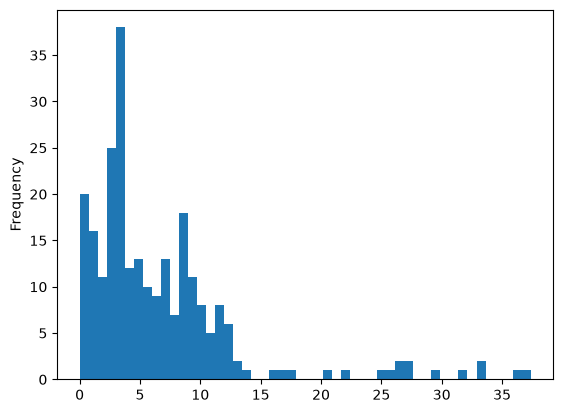

In [49]:
intersections['distance'].plot(kind='hist', bins=50)

In [59]:
p = figure(title='demo', x_axis_label='x', y_axis_label='y', match_aspect=True)
p.grid.grid_line_color = None

df = pd.DataFrame({
    'x': plot_coords['point'].x,
    'y': plot_coords['point'].y,
    'c': plot_coords['pathloc'],
})

cmap = linear_cmap('c', palette="Viridis256", low=0, high=1)
r = p.scatter(x='x', y='y', color=cmap, size=8, source=df)

xs = list(measurements['point'].x)
ys = list(measurements['point'].y)
ts = list(measurements['name'])

p.line(x=xs, y=ys, color='black')
p.scatter(x=xs, y=ys, size=3, color='black')
p.text(x=xs, y=ys, text=ts, x_offset=5, y_offset=-5)

color_bar = r.construct_color_bar(padding=0, ticker=p.xaxis.ticker, formatter=p.xaxis.formatter)
p.add_layout(color_bar, 'below')

show(p)

In [60]:
def vertical(row):
    match row.orientation:
        case 'SE': sign = 1 if row['point'].y > row['loc'].y else -1
        case 'SW': sign = 1 if row['point'].x > row['loc'].x else -1
        case 'NW': sign = 1 if row['point'].y < row['loc'].y else -1
        case 'NE': sign = 1 if row['point'].x < row['loc'].x else -1
    return sign * Point.distance(row['loc'],row['point'])

In [61]:

p = figure(title='linearized', height=300, width=1000, x_axis_label='x', y_axis_label='y', y_range=(-50,30))
p.grid.grid_line_color = None

p.line(x=[-0.01,1.02], y=[0,0], color='lightgray', line_width=100)
p.line(x=[0,1], y=[0,0], color='black', line_width=2)

px = []
py = []

for i, row in plot_coords.iterrows():
    xs = [row.pathloc, row.pathloc]
    ys = [0, vertical(row)]
    px.append(xs[-1])
    py.append(ys[-1])
    p.line(xs, ys)

yellow = Sunset10[5]
p.scatter(x=px, y=py, size=8, fill_color=yellow)    


show(p)